In [ ]:
import matplotlib.pyplot as plt
import torch
from glob import glob
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    recall_score,
    fbeta_score,
    precision_score,
)
from hashlib import sha256
from pathlib import Path
import pandas as pd

In [ ]:
preds = torch.unique(
    torch.cat(
        [
            torch.load(f)
            for f in glob(
                "/kaggle/working/sep25_alt1_mle_ds_covid1/logs/train/runs/2026-03-08_18-36-35/tensorboard/version_0/*.pt"
            )
        ]
    ),
    dim=0,
)

In [ ]:
y_pred = preds[:, -3:-1].argmax(1).numpy()
y_true = preds[:, -1].numpy()

In [ ]:
cm = confusion_matrix(y_true, y_pred)

In [ ]:
fbeta_score(y_true, y_pred, beta=1)

0.8307692307692308

In [ ]:
recall_score(y_true, y_pred)

0.7852865697177075

In [ ]:
precision_score(y_true, y_pred)

0.8818443804034583

In [ ]:
display = ConfusionMatrixDisplay(cm, display_labels=["Sain", "Malade"])

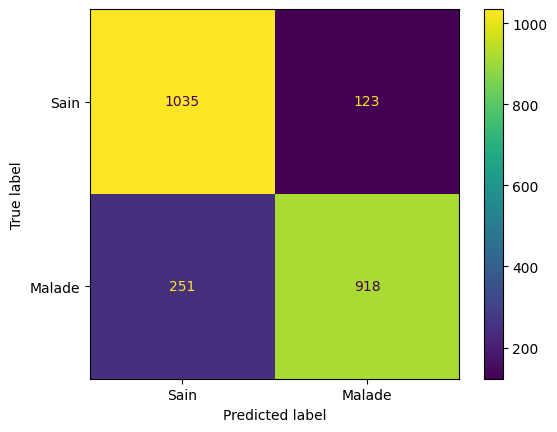

In [ ]:
display.plot()
plt.show()

In [ ]:
tp = (y_true == 1) & (y_pred == 1)
tn = (y_true == 0) & (y_pred == 0)
fp = (y_true == 0) & (y_pred == 1)
fn = (y_true == 1) & (y_pred == 0)

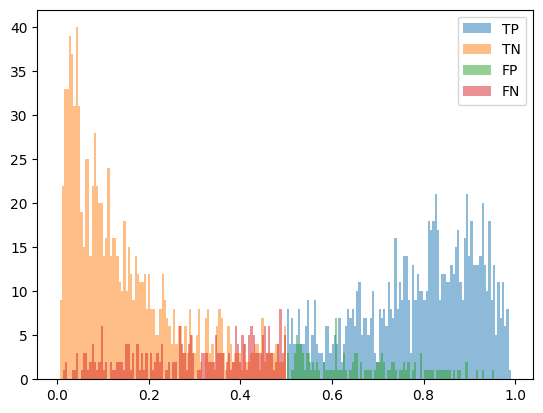

In [ ]:
plt.hist(preds[:, -2][tp], bins=100, label="TP", alpha=0.5)
plt.hist(preds[:, -2][tn], bins=100, label="TN", alpha=0.5)
plt.hist(preds[:, -2][fp], bins=100, label="FP", alpha=0.5)
plt.hist(preds[:, -2][fn], bins=100, label="FN", alpha=0.5)

plt.legend()
plt.show()

In [ ]:
ids = preds[:, 0]

In [ ]:
mnfst = pd.read_parquet(
    "/kaggle/working/sep25_alt1_mle_ds_covid1/data/02_manifests/manifest_ft_full.parquet"
)

In [ ]:
paths = mnfst.image.unique().tolist()

In [ ]:
d = {
    int(sha256(Path(path).stem.encode()).hexdigest()[:8], 16): Path(path).stem.split(
        "-"
    )[0]
    for path in paths
}

In [ ]:
fp_ids = ids[fp]
fn_ids = ids[fn]

fp_paths = [d[int(i)] for i in fp_ids]
fn_paths = [d[int(i)] for i in fn_ids]